In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
import zipfile
import os

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# See what files are inside
os.listdir('.')

['.config',
 'archive.zip',
 'WA_Fn-UseC_-Telco-Customer-Churn.csv',
 'sample_data']

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Check column names and data types
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
Payment

In [8]:
# Fix TotalCharges column - convert to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# This creates a few NaN values - fill them with 0
df['TotalCharges'].fillna(0, inplace=True)

# Convert Churn to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Churn value counts:")
print(df['Churn'].value_counts())
print("\nChurn %:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn value counts:
Series([], Name: count, dtype: int64)

Churn %:
Series([], Name: proportion, dtype: float64)


/tmp/ipykernel_7061/3078778768.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [10]:
print(df['Churn'].unique())

[nan]


In [11]:
# Reload fresh
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Fix Churn
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Verify
print(df['Churn'].value_counts())
print("\nChurn %:")
print(round(df['Churn'].value_counts(normalize=True) * 100, 2))

Churn
0    5174
1    1869
Name: count, dtype: int64

Churn %:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


/tmp/ipykernel_7061/2900622557.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


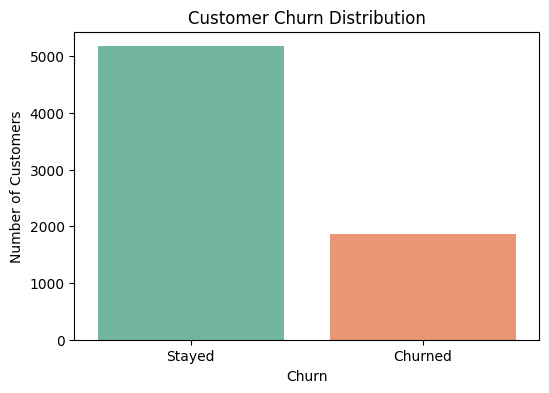

In [12]:
# Chart 1 - Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Customer Churn Distribution')
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.ylabel('Number of Customers')
plt.show()

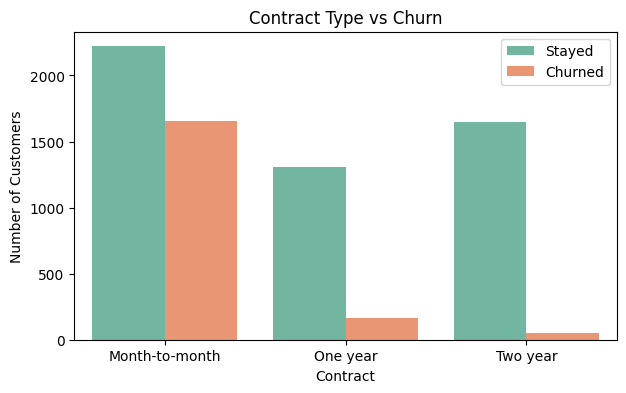

In [13]:
# Chart 2 - Contract Type vs Churn
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Contract Type vs Churn')
plt.legend(['Stayed', 'Churned'])
plt.ylabel('Number of Customers')
plt.show()

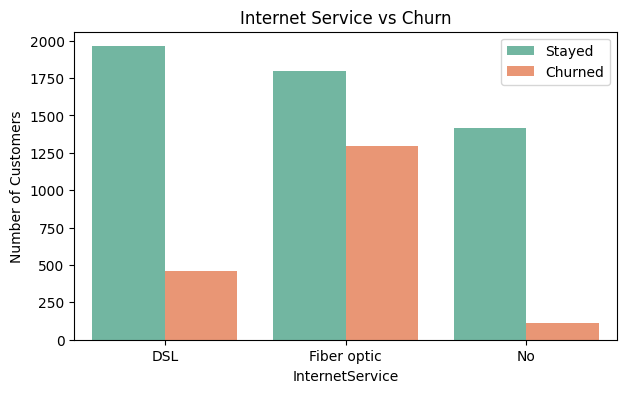

In [14]:
# Chart 3 - Internet Service vs Churn
plt.figure(figsize=(7,4))
sns.countplot(x='InternetService', hue='Churn', data=df, palette='Set2')
plt.title('Internet Service vs Churn')
plt.legend(['Stayed', 'Churned'])
plt.ylabel('Number of Customers')
plt.show()

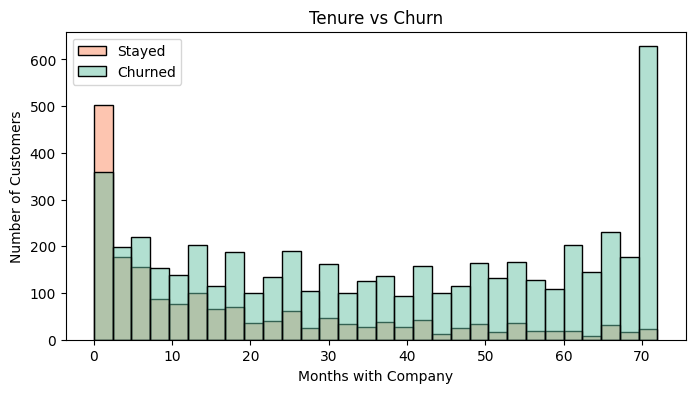

In [15]:
# Chart 4 - Tenure vs Churn
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Set2')
plt.title('Tenure vs Churn')
plt.xlabel('Months with Company')
plt.ylabel('Number of Customers')
plt.legend(['Stayed', 'Churned'])
plt.show()

/tmp/ipykernel_7061/3535000873.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', data=df, y='MonthlyCharges', palette='Set2')


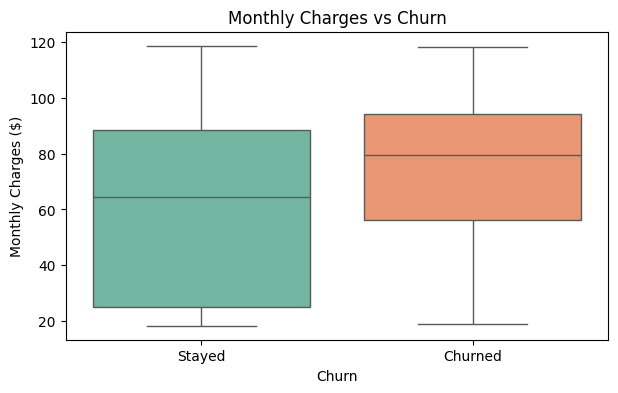

In [16]:
# Chart 5 - Monthly Charges vs Churn
plt.figure(figsize=(7,4))
sns.boxplot(x='Churn', data=df, y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges vs Churn')
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.ylabel('Monthly Charges ($)')
plt.show()

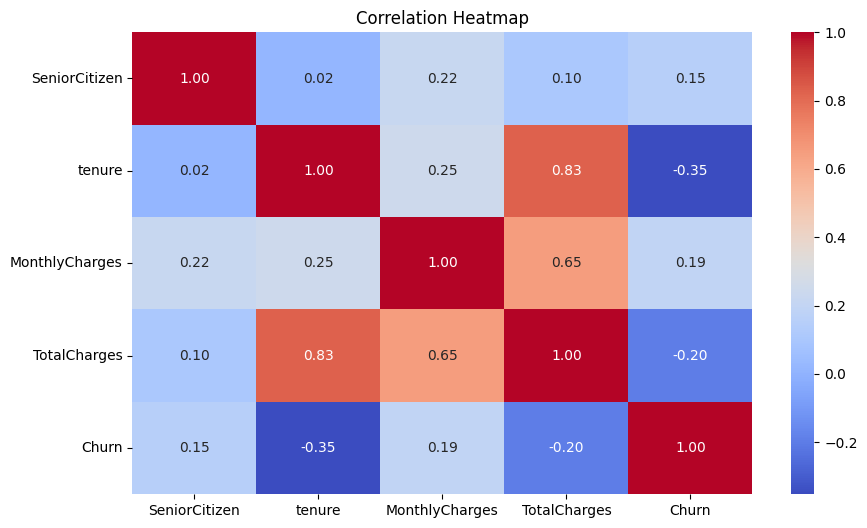

In [17]:
# Final Summary - Heatmap of correlations
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [18]:
# Final Insights Summary
print("=" * 50)
print("   CUSTOMER CHURN ANALYSIS - KEY FINDINGS")
print("=" * 50)
print(f"\n1. Overall Churn Rate: 26.54%")
print(f"   → 1 in 4 customers is leaving!")
print(f"\n2. Month-to-Month contracts churn the most")
print(f"   → Offer yearly plan discounts")
print(f"\n3. Fiber Optic users churn more")
print(f"   → Improve service quality/pricing")
print(f"\n4. New customers (0-12 months) churn most")
print(f"   → Focus retention on new customers")
print(f"\n5. High monthly charges = more churn")
print(f"   → Offer loyalty discounts")
print("=" * 50)

   CUSTOMER CHURN ANALYSIS - KEY FINDINGS

1. Overall Churn Rate: 26.54%
   → 1 in 4 customers is leaving!

2. Month-to-Month contracts churn the most
   → Offer yearly plan discounts

3. Fiber Optic users churn more
   → Improve service quality/pricing

4. New customers (0-12 months) churn most
   → Focus retention on new customers

5. High monthly charges = more churn
   → Offer loyalty discounts
